<a href="https://colab.research.google.com/github/Luppouk/Atividades-Calculo-Numerico/blob/main/atividade1/CN_atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico - Atividade prática I

## Identificação e Divisão de Tarefas

Nome: Luan Groppo Viana

RA: 17710

Realizou: A, B

Nome: Rodrigo Lopes Marques

RA: 180385

Realizou: C

Nome: Leonardo

RA: 176558

Realizou: D

## 1. Preparação do ambiente

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import textwrap
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

def trunca(x, n):
    return math.trunc(10**n * x) / 10**n

## Parte A - truncamento e arredondamento

In [ ]:
values = [3.14159265, 98.76543, 0.00498765]
names = ['x1','x2','x3']
rows=[]
for name, x in zip(names, values):
    ea_t = []
    ea_r = []
    for n in range(5):
        f = 10 ** n
        trunc = trunca(x, n)
        rnd = round(x, n)
        Ea_t = abs(x - trunc)
        Er_t = Ea_t / abs(x)
        Ep_t = 100 * Er_t

        Ea_r = abs(x - rnd)
        Er_r = Ea_r / abs(x)
        Ep_r = 100 * Er_r

        ea_t.append(Ea_t)
        ea_r.append(Ea_r)

        rows.append([name, n, 'Truncamento', trunc, Ea_t, Er_t, Ep_t])
        rows.append([name, n, 'Arredondamento', rnd, Ea_r, Er_r, Ep_r])

    plt.figure()
    plt.semilogy(range(5), ea_t, 'o-', label = 'Truncamento')
    plt.semilogy(range(5), ea_r, 's-', label = 'Arredondamento')
    plt.xlabel('n')
    plt.ylabel('Ea')
    plt.title(f'Erro absoluto - {name}')
    plt.grid(True)
    plt.legend()
    plt.savefig(f'parteA_{name}.png', dpi = 300, bbox_inches = 'tight')
    plt.close()

pd.DataFrame(rows,columns=['valor', 'n', 'metodo', 'aprox', 'Ea', 'Er', 'E%']).to_csv('parteA_tabela.csv',index = False)

#RESPOSTA PERGUNTA:
#Sim, o arredondamento sempre apresenta um erro menor ou igual que o truncamento.
#Isso ocorre pois o arredondamento escolhe a representação mais próxima do número
#com N números significativos, enquanto o truncamento apenas descarta os
#dígitos após a enesima casa decimal, sem considerar sua influência na aproximação

## Parte B - medidas de pressão arterial

In [ ]:
press = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
round_i = np.rint(press)
trunc_i = np.trunc(press)

ref_mean = press.mean()

stats = []
for nome, serie in [('Original', press), ('Arredondado', round_i), ('Truncado', trunc_i)]:
    mean = np.mean(serie)
    ea = abs(mean - ref_mean)
    er = ea / ref_mean
    ep = 100 * er
    stats.append([
        nome, mean, np.min(serie), np.max(serie),
        np.max(serie) - np.min(serie),
        np.std(serie, ddof = 1), ea, er, ep
    ])

pd.DataFrame(stats, columns = ['Serie', 'Media', 'Min', 'Max', 'Amplitude', 'DP', 'Ea', 'Er', 'E%']).to_csv('parteB_estatisticas.csv', index = False)

plt.figure(figsize = (9, 4))
plt.plot(press, 'o-', label = 'Original')
plt.plot(round_i, 's-', label = 'Arred.')
plt.plot(trunc_i, '^-', label = 'Trunc.')
plt.legend()
plt.grid(True)
plt.savefig('parteB_medicoes.png', dpi = 300)
plt.close()

erro_abs = [x[6] for x in stats]
plt.figure(figsize=(7, 4))
plt.bar(["Original", "Arredondado", "Truncado"],
        erro_abs,
        color=["green", "orange", "red"])
plt.title("Erro Absoluto da Média em Relação à Série Original")
plt.xlabel("Séries")
plt.ylabel("Erro Absoluto")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('parteB_erro_absoluto.png', dpi=300, bbox_inches='tight')
plt.close()

erro_pct = [x[8] for x in stats]
plt.figure(figsize=(7, 4))
plt.bar(["Original", "Arredondado", "Truncado"],
        erro_pct,
        color=["green", "orange", "red"])
plt.title("Erro Percentual da Média em Relação à Série Original")
plt.xlabel("Séries")
plt.ylabel("Erro Percentual (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('parteB_erro_percentual.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(7, 4))
plt.hist(press, bins=6, alpha=0.6, label='Original', color='green')
plt.hist(round_i, bins=6, alpha=0.6, label='Arredondado', color='orange')
plt.title("Histograma - Dados Originais x Arredondados")
plt.xlabel("Pressão sistólica (mmHg)")
plt.ylabel("Frequência")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('parteB_histograma.png', dpi=300, bbox_inches='tight')
plt.close()


## Parte C - vazão em um tubo de pequeno diâmetro

### C.1 Precisão das variáveis

In [ ]:
def Q(r_mm, mi, dp, L=0.20):
    r = r_mm * 1e-3
    return math.pi * r**4 * dp / (8 * mi * L)

r0 = 0.80 # mm
L = 0.20 # m
mi0 = 3.5e-3 # Pas
dp0 = 1200.0 # Pa

Qref = Q(r0, mi0, dp0)

casos = [
    ("todos os valores", r0, mi0, dp0),
    ("r arredondado", round(r0, 1), mi0, dp0),
    ("r truncado", trunca(r0, 1), mi0, dp0),
    ("mi arredondada", r0, round(mi0, 3), dp0),
    ("mi truncada", r0, trunca(mi0, 3), dp0),
    ("dp arredondada", r0, mi0, round(dp0, -2)),
    ("dp truncada", r0, mi0, trunca(dp0, -2)),
    ("todas arredondadas", round(r0, 1), round(mi0, 3), round(dp0, -2)),
    ("todas truncadas", trunca(r0, 1), trunca(mi0, 3), trunca(dp0, -2)),
]

print(f"Qref = {Qref:.6e} m^3/s")
for nome, r, mi, dp in casos:
    q  = Q(r, mi, dp)
    ea = abs(q - Qref)
    er = ea / abs(Qref)
    ep = er * 100
    print(f"{nome:<20} Q={q:.5e}  erro absoluto={ea:.3e}  erro relativo={er:.3e}  erro percentual={ep:.4f}%")


Qref = 2.757421e-07 m^3/s
todos os valores     Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
r arredondado        Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
r truncado           Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
mi arredondada       Q=2.41274e-07  erro absoluto=3.447e-08  erro relativo=1.250e-01  erro percentual=12.5000%
mi truncada          Q=3.21699e-07  erro absoluto=4.596e-08  erro relativo=1.667e-01  erro percentual=16.6667%
dp arredondada       Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
dp truncada          Q=2.75742e-07  erro absoluto=0.000e+00  erro relativo=0.000e+00  erro percentual=0.0000%
todas arredondadas   Q=2.41274e-07  erro absoluto=3.447e-08  erro relativo=1.250e-01  erro percentual=12.5000%
todas truncadas      Q=3.21699e-07  erro absoluto=4.596e-08  erro relativo=1.667e-01  erro 

### C.2 Sensibilidade

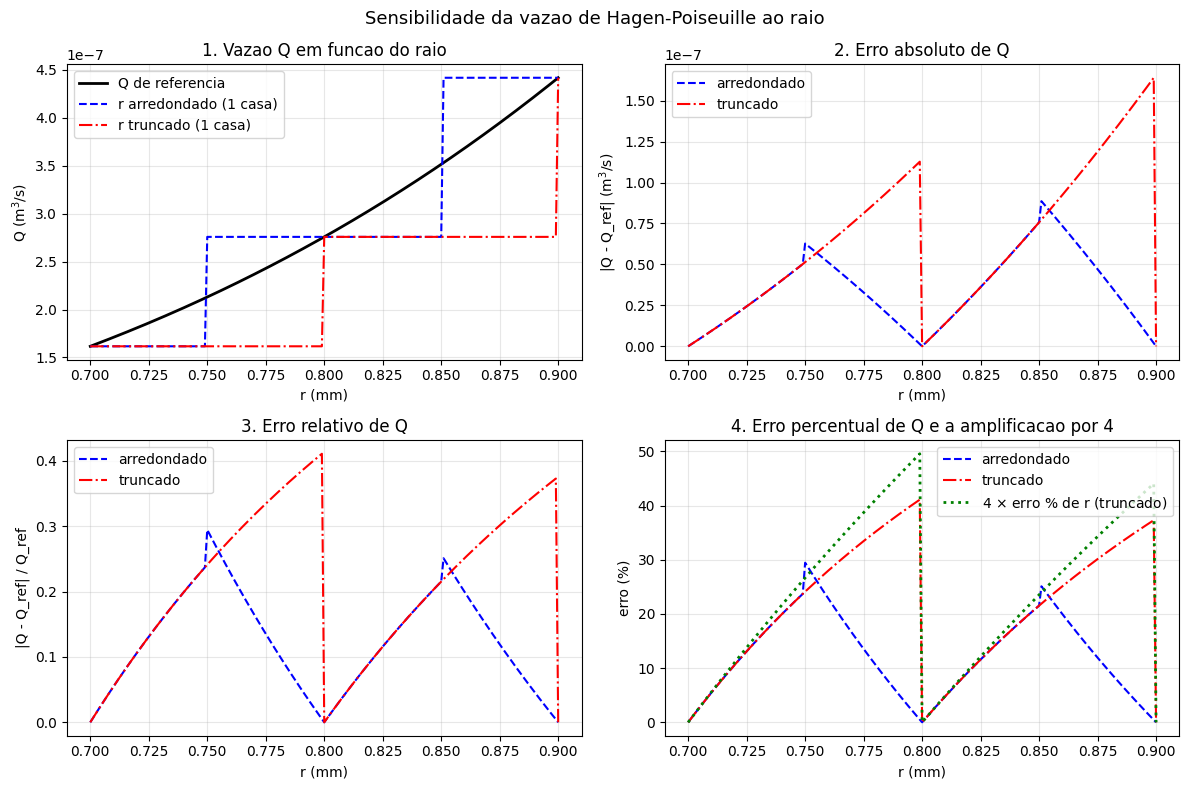

In [ ]:
# C.2

r_inicial = 0.70
r_final = 0.90

# array de valores dos raios
raios       = np.round(np.linspace(r_inicial, r_final, 201), 10)
raios_arr   = np.round(raios, 1)
raios_trunc = np.trunc(raios * 10) / 10

# array dos valores de Q para cada raio
Q_ref   = Q(raios, mi0, dp0)
Q_arr   = Q(raios_arr, mi0, dp0)
Q_trunc = Q(raios_trunc, mi0, dp0)

# array dos erros absoluto, relativo e percentual
ea_arr = abs(Q_arr - Q_ref)
ea_trunc = abs(Q_trunc - Q_ref)

er_arr = ea_arr / Q_ref
er_trunc = ea_trunc / Q_ref

ep_arr = er_arr * 100
ep_trunc = er_trunc * 100

# erro percentual do proprio raio truncado
ep_r_trunc = 100 * (abs(raios_trunc - raios) / raios)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Q em funcao de r
ax[0,0].plot(raios, Q_ref, 'k-', lw=2, label='Q de referencia')
ax[0,0].plot(raios, Q_arr, 'b--', lw=1.5, label='r arredondado (1 casa)')
ax[0,0].plot(raios, Q_trunc, 'r-.', lw=1.5, label='r truncado (1 casa)')
ax[0,0].set_xlabel('r (mm)'); ax[0,0].set_ylabel('Q (m$^3$/s)')
ax[0,0].set_title('1. Vazao Q em funcao do raio')

# 2. erro absoluto
ax[0,1].plot(raios, ea_arr, 'b--', lw=1.5, label='arredondado')
ax[0,1].plot(raios, ea_trunc, 'r-.', lw=1.5, label='truncado')
ax[0,1].set_xlabel('r (mm)'); ax[0,1].set_ylabel('|Q - Q_ref| (m$^3$/s)')
ax[0,1].set_title('2. Erro absoluto de Q')

# 3. erro relativo
ax[1,0].plot(raios, er_arr, 'b--', lw=1.5, label='arredondado')
ax[1,0].plot(raios, er_trunc, 'r-.', lw=1.5, label='truncado')
ax[1,0].set_xlabel('r (mm)'); ax[1,0].set_ylabel('|Q - Q_ref| / Q_ref')
ax[1,0].set_title('3. Erro relativo de Q')

# 4. erro percentual, comparado com 4x o erro relativo do raio
ax[1,1].plot(raios, ep_arr, 'b--', lw=1.5, label='arredondado')
ax[1,1].plot(raios, ep_trunc, 'r-.', lw=1.5, label='truncado')
ax[1,1].plot(raios, 4*ep_r_trunc, 'g:', lw=2, label=r'4 $\times$ erro % de r (truncado)')
ax[1,1].set_xlabel('r (mm)'); ax[1,1].set_ylabel('erro (%)')
ax[1,1].set_title('4. Erro percentual de Q e a amplificacao por 4')

for eixo in ax.flat:
    eixo.legend()
    eixo.grid(alpha=0.3)

fig.suptitle('Sensibilidade da vazao de Hagen-Poiseuille ao raio', fontsize=13)
fig.tight_layout()
plt.show()


#### Explicação do porque o erro no raio é amplificado na vazão
Na equação de Hagen-Poiseuille, a vazão é proporcional ao raio elevado à quarta potência, então um erro relativo no raio entra na conta quatro vezes. Se o raio erra 1%, a vazão erra cerca de 4%.

## Parte D - escoamento em um nanocateter

In [ ]:
def h(r, d_p, mi, L):
  Q = (math.pi * (r** 4) * d_p)/(8*mi*L)
  return Q

def delta_1(r, delta_r, d_p, mi, L):
    Q_atual = h(r, d_p, mi, L)
    Q_novo = h(r + delta_r, d_p, mi, L)
    return (Q_novo - Q_atual) / Q_atual

def delta_2(r, delta_r):
    return ((1 + delta_r / r) ** 4) - 1

r = 50 #nm
d_p = 5000  #Pa.
mi = 0.0035 #Pa s
L = 10 #μm

Q = h(r,d_p, mi,L)

print("Qref =", Q)

Qref = 350624180088.1465


### D.1 Erro geométrico

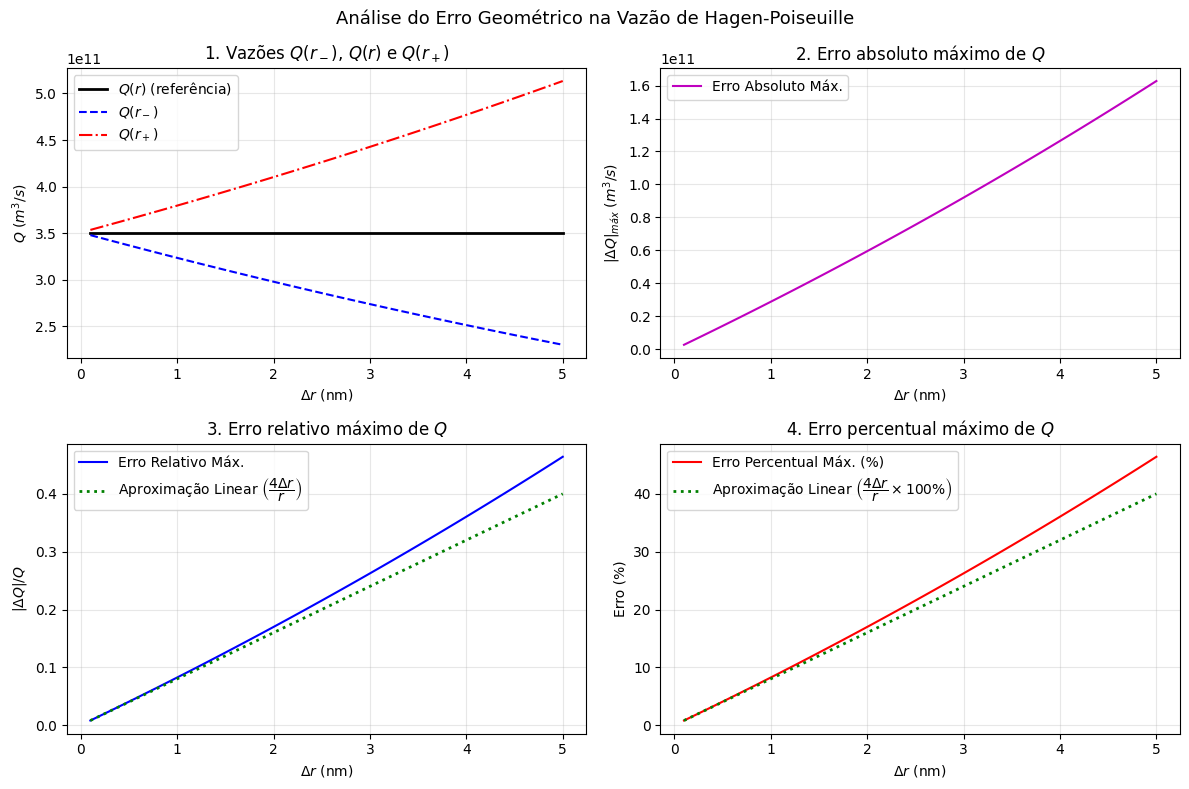

In [ ]:
x = np.linspace(0.1, 5, 50, dtype=np.float64)

y0 = [] #r
y1 = [] #r-
y2 = [] #r+

maior_absoluto = []

y3 = [] #rel
y4 = [] #per

y5 = [] #aproximacao linear

for _ in x:
  y0.append(Q)

for d_r in x:
  y1.append(abs(Q - h(r-d_r,d_p, mi,L)))
  y2.append(abs(Q - h(r+d_r,d_p, mi,L)))

for i in range(50):
  maior_absoluto.append(max(y1[i],y2[i]))

for i in range(50):
  y3.append(maior_absoluto[i]/Q)

for i in range(50):
  y4.append(100*y3[i])

for d_r in x:
  y5.append((4 * d_r) / r)

# print (y5)

# Criando a figura com os 4 subplots (2x2)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Vazões Q(r-), Q(r) e Q(r+)
# Como y1 e y2 armazenam |Q - Q(r±)|, recriamos as curvas de vazão reais para exibição:
ax[0, 0].plot(x, y0, 'k-', lw=2, label=r'$Q(r)$ (referência)')
ax[0, 0].plot(x, [q - e for q, e in zip(y0, y1)], 'b--', lw=1.5, label=r'$Q(r_-)$')
ax[0, 0].plot(x, [q + e for q, e in zip(y0, y2)], 'r-.', lw=1.5, label=r'$Q(r_+)$')
ax[0, 0].set_xlabel(r'$\Delta r$ (nm)')
ax[0, 0].set_ylabel(r'$Q$ ($m^3/s$)')
ax[0, 0].set_title(r'1. Vazões $Q(r_-)$, $Q(r)$ e $Q(r_+)$')

# 2. Erro absoluto máximo
ax[0, 1].plot(x, maior_absoluto, 'm-', lw=1.5, label='Erro Absoluto Máx.')
ax[0, 1].set_xlabel(r'$\Delta r$ (nm)')
ax[0, 1].set_ylabel(r'$|\Delta Q|_{máx}$ ($m^3/s$)')
ax[0, 1].set_title(r'2. Erro absoluto máximo de $Q$')

# 3. Erro relativo máximo
ax[1, 0].plot(x, y3, 'b-', lw=1.5, label='Erro Relativo Máx.')
ax[1, 0].plot(x, y5, 'g:', lw=2, label=r'Aproximação Linear $\left(\dfrac{4\Delta r}{r}\right)$')
ax[1, 0].set_xlabel(r'$\Delta r$ (nm)')
ax[1, 0].set_ylabel(r'$|\Delta Q| / Q$')
ax[1, 0].set_title(r'3. Erro relativo máximo de $Q$')

# 4. Erro percentual máximo
ax[1, 1].plot(x, y4, 'r-', lw=1.5, label='Erro Percentual Máx. (%)')
ax[1, 1].plot(x, [val * 100 for val in y5], 'g:', lw=2, label=r'Aproximação Linear $\left(\dfrac{4\Delta r}{r} \times 100\%\right)$')
ax[1, 1].set_xlabel(r'$\Delta r$ (nm)')
ax[1, 1].set_ylabel('Erro (%)')
ax[1, 1].set_title(r'4. Erro percentual máximo de $Q$')

# Formatação global dos eixos
for eixo in ax.flat:
    eixo.legend()
    eixo.grid(True, alpha=0.3)

fig.suptitle('Análise do Erro Geométrico na Vazão de Hagen-Poiseuille', fontsize=13)
fig.tight_layout()

plt.show()


### D.2 Precisão computacional

np.float32
r²=  6250000.0
Q =  350624200000.0

np.float64
r²=  6250000.0
Q =  350624180088.1465

Erro absoluto: 6279.853515625
Erro relativo: 1.7910497221186953e-08

np.finfo(np.float32).eps: 1.1920929e-07
np.finfo(np.float64).eps: 2.220446049250313e-16


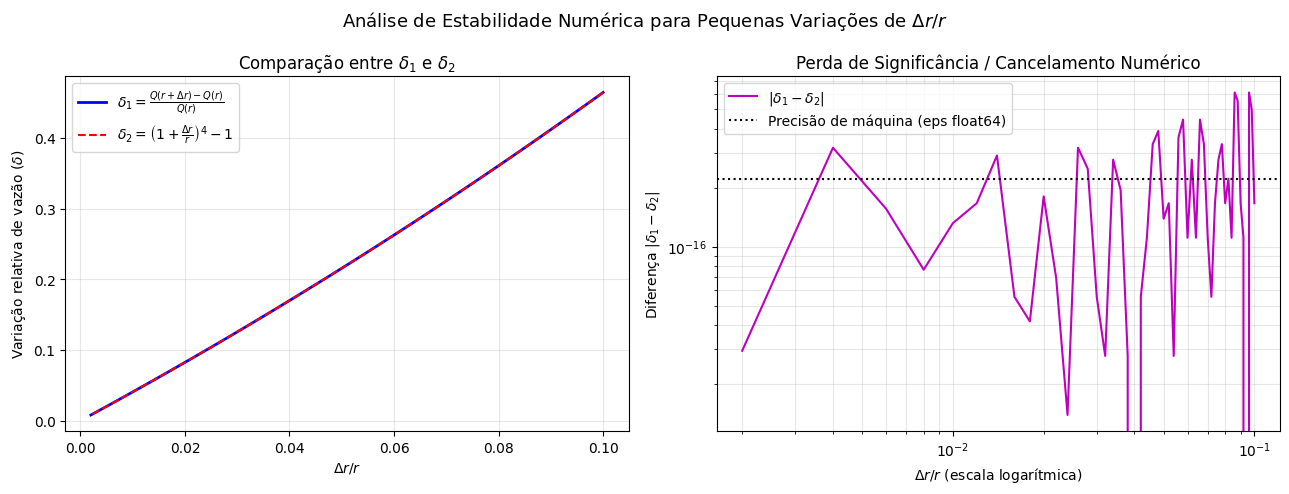

In [ ]:
print("np.float32")
r1 = np.float32(50) #nm
d_p1 = np.float32(5000)  #Pa.
mi1 = np.float32(0.0035) #Pa s
L1 = np.float32(10) #μm

print("r²= ", r1**4)

Q1 = h(r1,d_p1, mi1,L1)
print("Q = ", Q1)


print("\nnp.float64")
r2 = np.float64(50) #nm
d_p2 = np.float64(5000)  #Pa.
mi2 = np.float64(0.0035) #Pa s
L2 = np.float64(10) #μm

print("r²= ", r2**4)

Q2 = h(r2,d_p2, mi2,L2)
print("Q = ", Q2)


erro_r4abs = abs(Q1 - Q2)
print("\nErro absoluto:", erro_r4abs)

erro_r4rel = erro_r4abs / abs(Q1)
print("Erro relativo:", erro_r4rel)

print("\nnp.finfo(np.float32).eps:", np.finfo(np.float32).eps)
print("np.finfo(np.float64).eps:", np.finfo(np.float64).eps)



y6 = [] #delta1
y7 = [] #delta2

d_r2 = x[::-1]

for a in d_r2:
  y6.append(delta_1(r, a, d_p, mi, L))

for a in d_r2:
  y7.append(delta_2(r, a))




# Razão Delta_r / r para o eixo X
razao_dr_r = [a / r for a in d_r2]

# Erro absoluto entre os dois métodos de cálculo
erro_cancelamento = [abs(d1 - d2) for d1, d2 in zip(y6, y7)]

# 2. Criação das figuras (2 gráficos lado a lado)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: Comparação direta entre delta_1 e delta_2
ax[0].plot(razao_dr_r, y6, 'b-', lw=2, label=r'$\delta_1 = \frac{Q(r+\Delta r) - Q(r)}{Q(r)}$')
ax[0].plot(razao_dr_r, y7, 'r--', lw=1.5, label=r'$\delta_2 = \left(1 + \frac{\Delta r}{r}\right)^4 - 1$')
ax[0].set_xlabel(r'$\Delta r / r$')
ax[0].set_ylabel(r'Variação relativa de vazão ($\delta$)')
ax[0].set_title(r'Comparação entre $\delta_1$ e $\delta_2$')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Gráfico 2: Erro por cancelamento numérico (escala logarítmica)
ax[1].plot(razao_dr_r, erro_cancelamento, 'm-', lw=1.5, label=r'$|\delta_1 - \delta_2|$')
ax[1].axhline(y=np.finfo(np.float64).eps, color='k', linestyle=':', label='Precisão de máquina (eps float64)')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$\Delta r / r$ (escala logarítmica)')
ax[1].set_ylabel(r'Diferença $|\delta_1 - \delta_2|$')
ax[1].set_title('Perda de Significância / Cancelamento Numérico')
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)

fig.suptitle(r'Análise de Estabilidade Numérica para Pequenas Variações de $\Delta r / r$', fontsize=13)
fig.tight_layout()

plt.show()

# falta comentar sobre delta1 e delta2

### D.3 Fenômeno físico

## Parte E - síntese visual

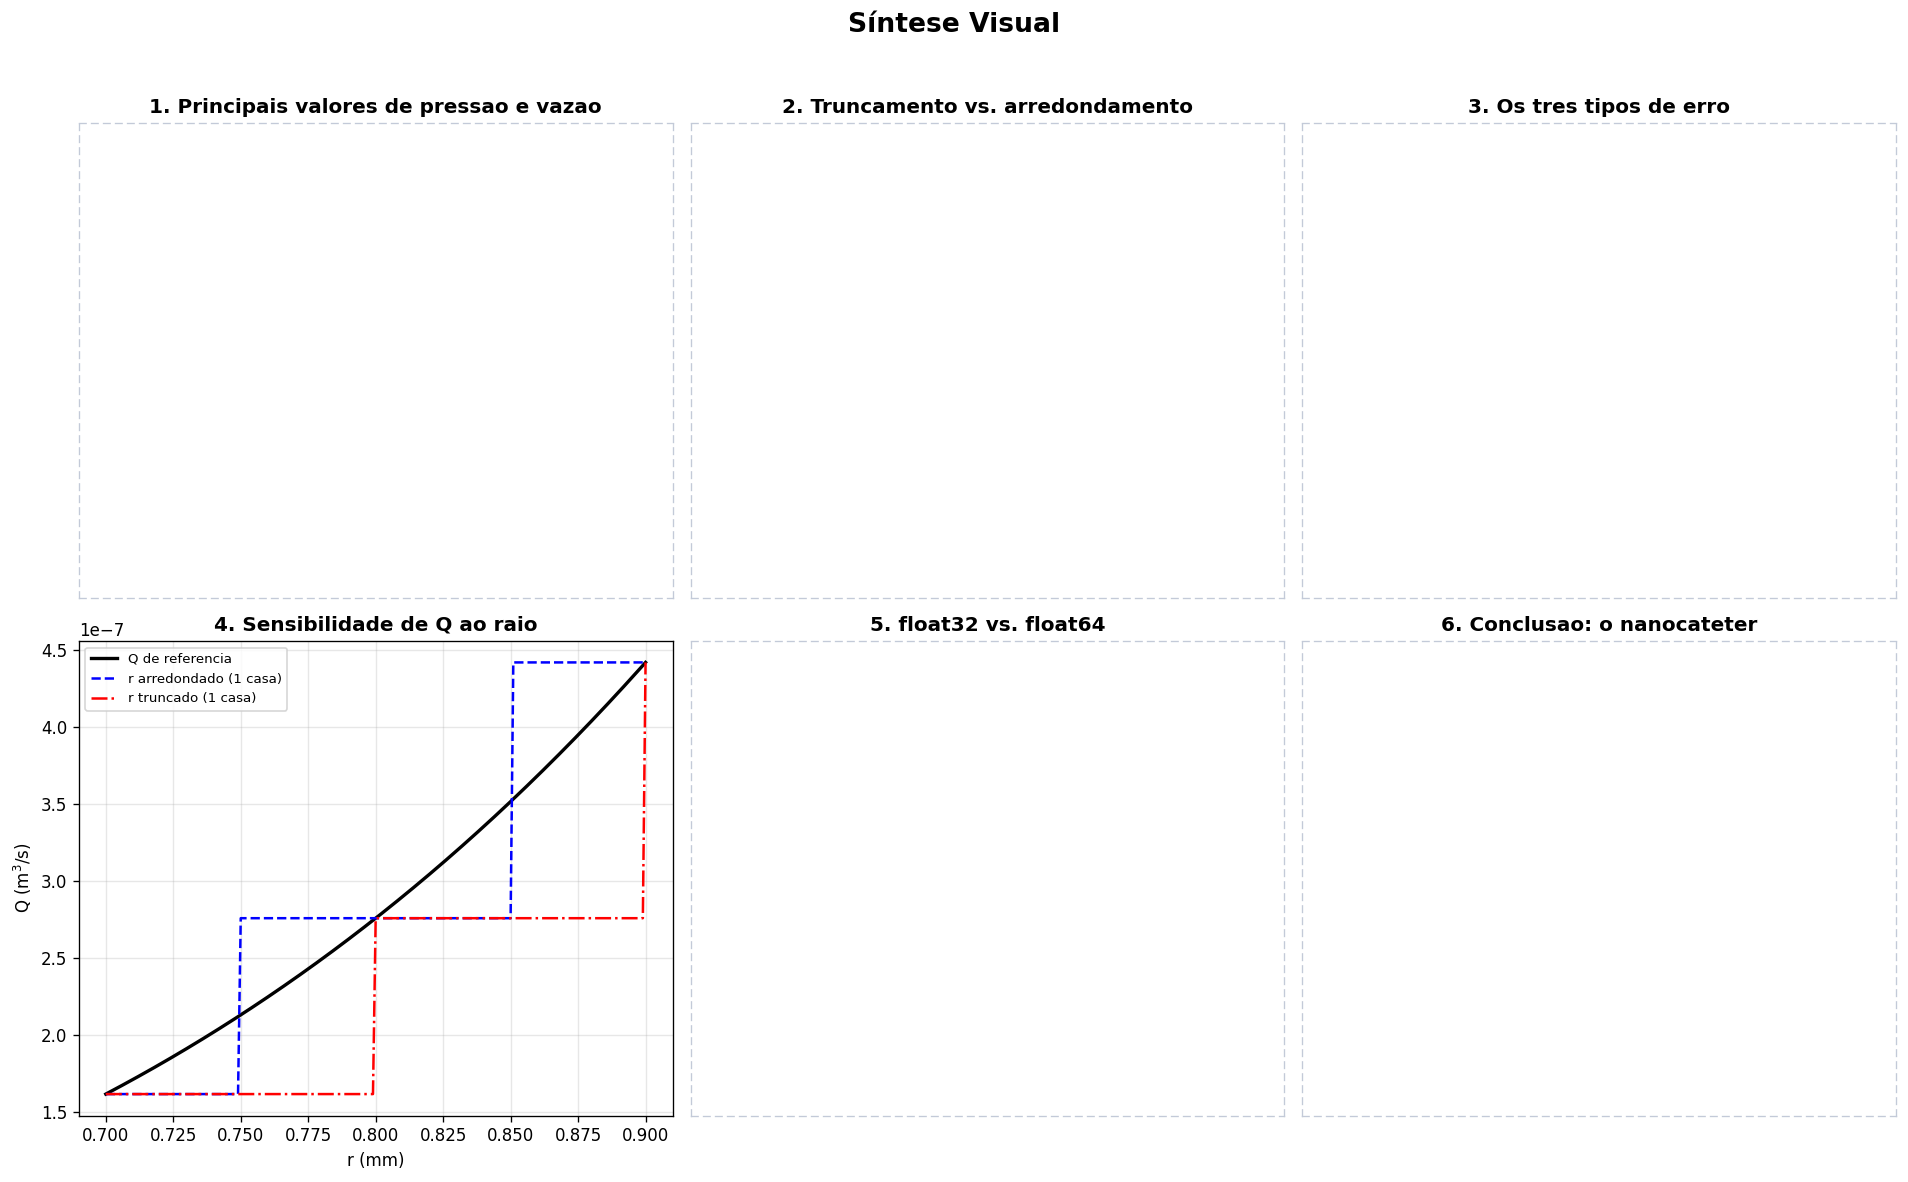

salvo em 1920 x 1200 px


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

DPI = 120                                   # 16x10 pol * 120 = 1920x1200 px


def painel_reservado(ax, autor=""):
    """Placeholder: mantem o espaco no layout ate o grafico ficar pronto."""
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_linestyle((0, (5, 4))); s.set_edgecolor("#c3cad8")


def painel_sensibilidade(ax):
    """4. Vazao Q em funcao do raio (usa as variaveis da celula C.2)."""
    ax.plot(raios, Q_ref, "k-", lw=2, label="Q de referencia")
    ax.plot(raios, Q_arr, "b--", lw=1.5, label="r arredondado (1 casa)")
    ax.plot(raios, Q_trunc, "r-.", lw=1.5, label="r truncado (1 casa)")
    ax.set_xlabel("r (mm)"); ax.set_ylabel("Q (m$^3$/s)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)


# ------------------------------------------------------------------- montagem
fig, ax = plt.subplots(2, 3, figsize=(16, 10), dpi=DPI, facecolor="white")

titulos = [
    "1. Principais valores de pressao e vazao",
    "2. Truncamento vs. arredondamento",
    "3. Os tres tipos de erro",
    "4. Sensibilidade de Q ao raio",
    "5. float32 vs. float64",
    "6. Conclusao: o nanocateter",
]
for eixo, t in zip(ax.flat, titulos):
    eixo.set_title(t, fontsize=12, fontweight="bold")

painel_reservado(ax[0, 0], "Espaço Reservado")
painel_reservado(ax[0, 1], "Espaço Reservado")
painel_reservado(ax[0, 2], "Espaço Reservado")
painel_sensibilidade(ax[1, 0])
painel_reservado(ax[1, 1], "Espaço Reservado")
painel_reservado(ax[1, 2], "Espaço Reservado")

fig.suptitle("Síntese Visual",
             fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig("quadro_resultados.png", dpi=DPI, facecolor="white")  # sem bbox_inches
plt.show()
print("salvo em", int(fig.get_size_inches()[0]*DPI), "x", int(fig.get_size_inches()[1]*DPI), "px")

## GIF demonstrativo